# Нейросеть для предсказания калорийности блюд

Выполнена задача создания и обучения нейросети, которая предсказывает калорийность блюд. Полученную модель можно интегрировать во многие fitness и health-приложения, она будет полезна тем, кто следит за своим здоровьем. 

### Этапы проекта

1) Проведен EDA датасета блюд, выявлен дисбаланс классов и определен подход: дообучение EfficientNet с аугментациями и метрикой взвешенной F1.
2) Реализован воспроизводимый пайплайн обучения в dataset.py и utils.py с функцией train(config).
3) Обучена модель на GPU ВМ, достигнуто F1=0.87.
4) Протестирована модель на тестовой выборке (F1=0.86), визуализированы топ‑5 худших примеров.

In [2]:
from functools import partial
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import timm
from torch.utils.data import Subset
import torchvision.models as models
import numpy as np
import tqdm as notebook_tqdm
from collections import Counter
import pandas as pd
import random
import torchmetrics
from transformers import AutoTokenizer

import albumentations as A

from sklearn.metrics import mean_absolute_error
from scripts.dataset import MultimodalDataset
from scripts.dataset import get_transforms, collate_fn
from scripts.utils import MultimodalModel, validate, seed_everything
from scripts.utils import train

import warnings
warnings.filterwarnings('ignore')

In [3]:
PATH_IMG = 'data/images'
PATH_CSV = 'data'
RANDOM_STATE  = 42

## Этап 1. Исследовательский анализ (EDA)

## Данные изображений

Для начала загрузим изображения и изучим их содержание.

In [4]:
# Загрузка датасета
dataset = ImageFolder(PATH_IMG)

# Выведем исходный размер картинок
img, label = dataset[0]
width, height = img.size
print(f"Ширина: {width}, Высота: {height}, количество {len(dataset)}")

Ширина: 640, Высота: 480, количество 3490


dish_1571944487
dish_1565725095
dish_1567538263


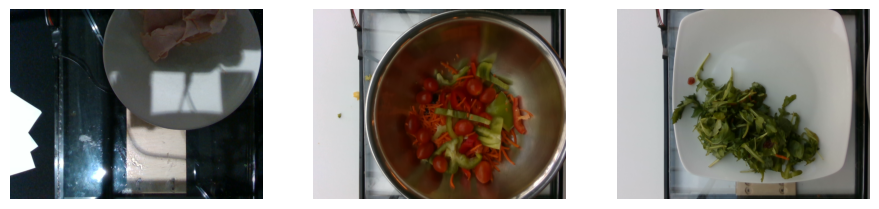

In [87]:
# Генерируем 3 неповторяющихся случайных индекса
total_samples = len(dataset)
random_indices = random.sample(range(total_samples), 3)

fig = plt.figure(figsize=(15, 5))
for plot_num, idx in enumerate(random_indices, start=1):
    image, label = dataset[idx]          
    print(dataset.classes[label])      
    plt.subplot(1, 4, plot_num)         
    plt.imshow(image)
    plt.axis('off')

plt.show()

Исходя из визуального анализа случайных изобоажений можно сделать следующие выводы по качеству картинок и содержанию:
1. В основном тарелки квадратные, белого цвета, но встречаются и круглые разного размера и цвета.
2. Тарелки в основном по стоят по центру изображения, продукты не всегда по центру тарелки.
3. Встречаются обрезанные изображения тарелок и продуктов на них.
4. Иногда на снимок с основным блюдом попадают другие частично другие тарелки и продукты на них.
5. Освещение в основном нормальное, но встречаются частично засвеченные снимки, когда часть продуктов на тарелке в тени.
6. Слишком смешанные блюда или часть продуктов лежит друг на друге.
7. Много маленьких деталей. Сами продукты на тарелке мелкие, еще на снимке присутсвуют провода, мелкие предметы вне тарелки. 

Чтобы модель могла эффективно различать продукты при различных конфигурациях снимка, предлагается реализовать следующие трансформации:
1. RandomResizedCrop - вырезает случайную область размером от 80% до 100% исходного изображения и масштабирует к 224×224. Это имитирует обрезанные тарелки, разный масштаб съёмки и смещение объекта от центра, заставляя модель распознавать блюдо по его характерным частям, а не по точному положению в кадре.
2. Rotate - поворот на угол до ±30°. Это добавляет вариативность ракурса, так как в реальных условиях тарелка может быть сфотографирована под наклоном.
3. HorizontalFlip - зеркальное отражение по горизонтали, не искажая смысл блюда, поскольку тарелки и еда часто обладают симметрией.
4. ColorJitter - случайное изменение яркости, контраста, насыщенности и оттенка. Компенсирует перепады освещения, засветы, тени, разный цвет тарелок и условия съёмки, делая модель более устойчивой к цветовым искажениям.
5. GaussNoise - добавление гауссовского шума. Имитирует съёмку при слабом освещении или артефакты сжатия, что повышает робастность модели к ухудшенному качеству изображения и расфокусу.
6. CoarseDropout - закрашивает чёрным случайные прямоугольные области. Это помогает модели игнорировать посторонние предметы (другие тарелки, провода, мелкий мусор).

## Табличные данные

Далее загрузим таблицы и изучим данные в них.

In [95]:
# Загрузим датасет с ингериентами
df_ing = pd.read_csv(f"{PATH_CSV}/ingredients.csv", index_col=False)

# Посмотрим на параметры датасета
df_ing.info()
df_ing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


В датасете ingredients.csv содержится словарь с ингредиентами. Скорее всего этот словарь не исчерпывающий и в нем далеко не все возможные существующие продукты.

In [197]:
# Загрузим датасет с описаниями блюд
df_dish = pd.read_csv(f"{PATH_CSV}/dish.csv", index_col=False)

# Посмотрим на параметры датасета
df_dish.info()
df_dish.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


Столбец total_calories - это таргет. По меткам split необходимо поделить датасет на трейн и тест. Столбец ingredients - список всех ID ингредиентов в формате ingr_0000000122;ingr_0000000026;.., где ненулевая часть соответствует ID ингредиента из ingredients.csv.

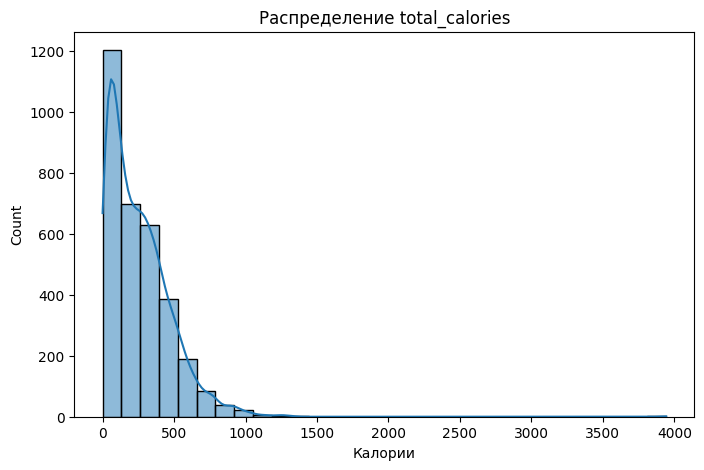

In [153]:
# Посмотрим на распределение таргета
plt.figure(figsize=(8,5))
sns.histplot(df_dish['total_calories'], bins=30, kde=True)
plt.title('Распределение total_calories')
plt.xlabel('Калории')
plt.show()

Распределение калорий имеет сильный сдвиг влево. Можно считать, что блюда с калорийностью выше 1500 - малочисленные и больше похожы на выбросы.

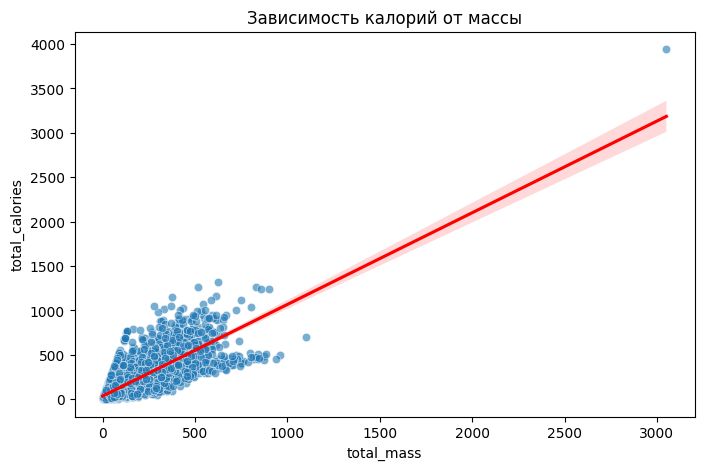

In [154]:
# Посмотрим как масса и калории зависят друг от друга
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_dish, x='total_mass', y='total_calories', alpha=0.6)
sns.regplot(data=df_dish, x='total_mass', y='total_calories', scatter=False, color='red')
plt.title('Зависимость калорий от массы')
plt.show()

На графике видно один экземпляр с массой 3кг и калорийностью 4000. Возможно в этом экземпляре какая-то ошибка в порядке значений. Найдем этот экземпляр и посмотрим на картинку. В целом, масса около 1кг и при этом калорийность меньше 500 тоже вызывают подозрения. Но поскольку в этой части распределение более менее равномерное, будем считать что это нормально.

In [164]:
# Найдем экземпляр с массой около 3кг
display(df_dish[df_dish['total_mass']>2000])

,dish_id,total_calories,total_mass,ingredients,split
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train


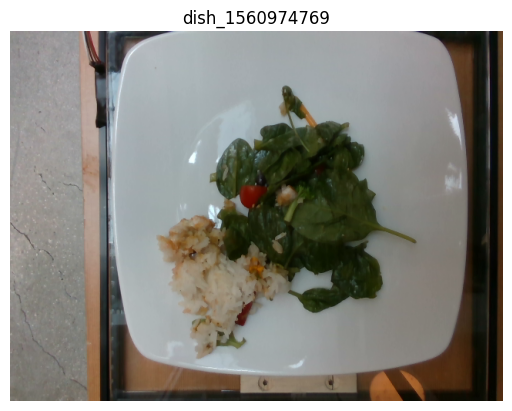

In [ ]:
# Найдем в датасете это блюдо
target_dish = 'dish_1560974769'

if target_dish in dataset.classes:
    class_idx = dataset.classes.index(target_dish)
    # Ищем первое изображение с этим классом
    for i, (_, label) in enumerate(dataset):
        if label == class_idx:
            image, _ = dataset[i]
            plt.imshow(image)
            plt.axis('off')
            plt.title(target_dish)
            plt.show()
            break

Не похоже, что горсть риса и немного зелени весит 3 кг. 

In [198]:
# Посчитаем количество ингредиентов для каждого блюда
df_dish['n_ingredients'] = df_dish['ingredients'].apply(lambda x: len(x.split(';')))

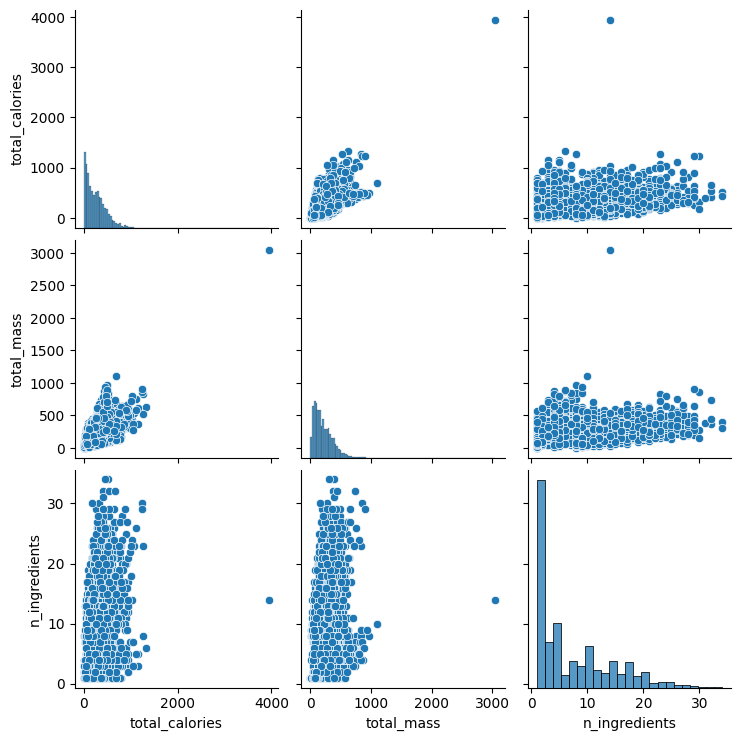

In [199]:
# Теперь посмотрим на зависимости числовых признаков
sns.pairplot(df_dish[['total_calories', 'total_mass', 'n_ingredients']])
plt.show()

За исключением 3-х килограмого блюда распределения выглядят нормально. Хотя количество блюд с большим количеством ингредиентов настораживает. Скорее всего модели будет сложно все их распознать.

In [200]:
# Посмотрим, какое количество блюд с 30+ ингредиентами
df_dish[df_dish['n_ingredients']>30]

,dish_id,total_calories,total_mass,ingredients,split,n_ingredients
756,dish_1561578461,522.154663,392.0,ingr_0000000025;ingr_0000000291;ingr_000000003...,train,34
961,dish_1563395510,415.627411,372.0,ingr_0000000027;ingr_0000000045;ingr_000000029...,train,32
1641,dish_1563565508,403.862000,387.0,ingr_0000000421;ingr_0000000189;ingr_000000003...,test,31
2025,dish_1561060703,538.466736,445.0,ingr_0000000203;ingr_0000000540;ingr_000000009...,train,32
2138,dish_1561579933,447.449249,306.0,ingr_0000000291;ingr_0000000031;ingr_000000016...,train,34
3137,dish_1561576794,654.721252,738.0,ingr_0000000189;ingr_0000000133;ingr_000000051...,train,32


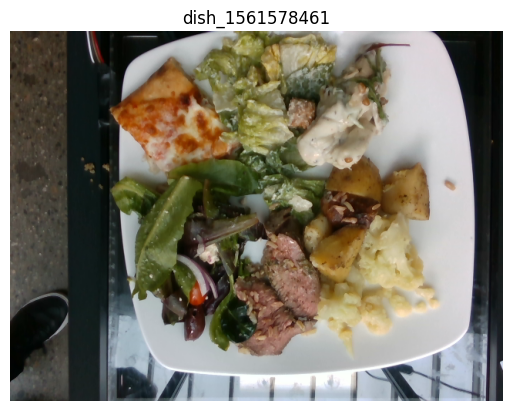

In [ ]:
# Найдем в датасете какое ни будь из этих блюд
target_dish = 'dish_1561578461'

if target_dish in dataset.classes:
    class_idx = dataset.classes.index(target_dish)
    # Ищем первое изображение с этим классом
    for i, (_, label) in enumerate(dataset):
        if label == class_idx:
            image, _ = dataset[i]
            plt.imshow(image)
            plt.axis('off')
            plt.title(target_dish)
            plt.show()
            break

В целом, если считать ингредиенты подробно, влоть до состава соуса и хлеба, можно набрать 34 ингредиента. Далее раскодируем ингредиенты, чтобы лучше понимать данные.

In [201]:
# Создадим отдельно словарь с идентификатором и ингредиентом
ingredient_map = dict(zip(df_ing['id'], df_ing['ingr']))

In [207]:
# Функция раскодировки
def decode_ingredients(ing_str):
    if pd.isna(ing_str):
        return ing_str
    codes = ing_str.split(';')
    names = []
    for code in codes:
        num_part = code.split('_')[1]
        ing_id = int(num_part)
        name = ingredient_map.get(ing_id, code)
        names.append(name)

    return ','.join(names)

# Применяем к столбцу в новом датасете
df_prep = df_dish.copy()
df_prep['ingredients'] = df_prep['ingredients'].apply(decode_ingredients)

In [129]:
# Посмотрим на результат
df_prep.sample(5)

,dish_id,total_calories,total_mass,ingredients,split
524,dish_1568313487,13.720000,49.0,mixed greens,train
1530,dish_1563389446,117.787598,173.0,"garlic, radishes, blueberries, spinach (raw), ...",train
296,dish_1560444892,39.540001,90.0,"honeydew melons, pineapple",test
2474,dish_1559933834,775.029236,458.0,"pepper, salmon, pears, parsley, lemon juice, l...",train
2730,dish_1558031675,248.882004,180.0,"yam, bacon, cantaloupe",train


In [208]:
# Получим все ингредиенты и их частоту
ingredients_list = []
for x in df_prep['ingredients']:
    ingredients_list.extend(x.split(','))

ingredient_counts = Counter(ingredients_list)
top_ingredients = [ing for ing, cnt in ingredient_counts.most_common(10)]  # топ-10

# Создадим столбцы для каждого топ-ингредиента
for ing in top_ingredients:
    df_prep[f'{ing}'] = df_prep['ingredients'].apply(lambda x: 1 if ing in x.split(',') else 0)

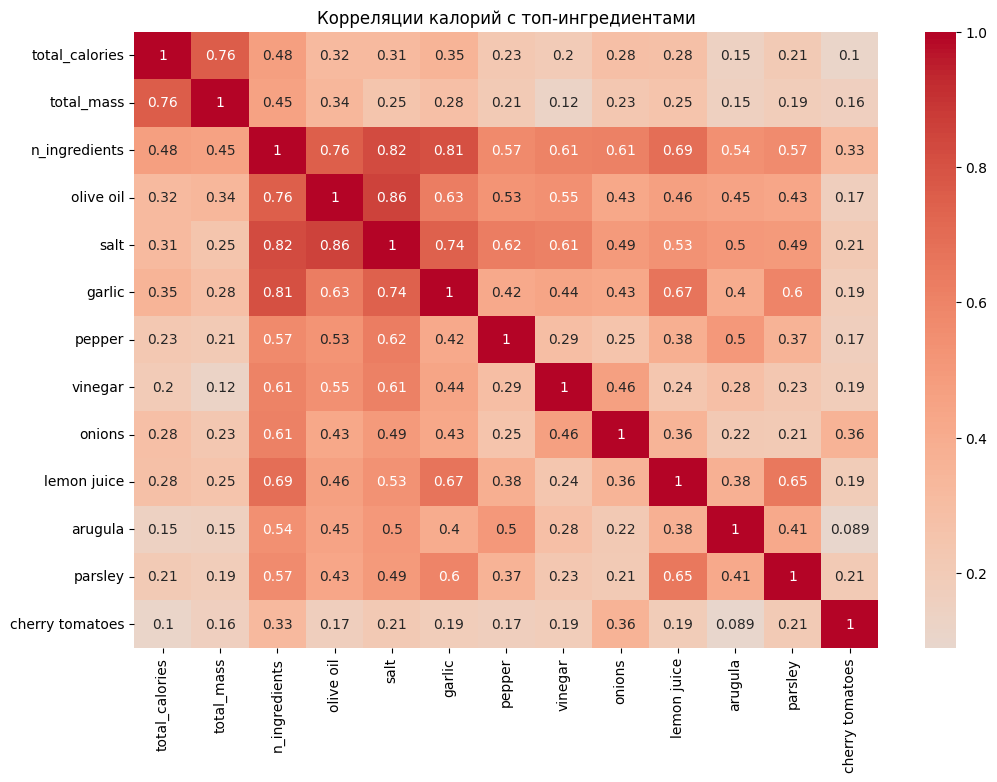

In [213]:
# Возмем калории и числовые столбцы
corr_data = df_prep[['total_calories'] + ['total_mass'] + ['n_ingredients'] + [f'{ing}' for ing in top_ingredients]]
corr_matrix = corr_data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляции калорий с топ-ингредиентами')
plt.show()

Такая матрица довольно бесполезна с точки зрения поиска каких-то дополнительных знаний о блюдах. Значения корреляций ниже среднего, а наибольшее влияние на калорийность оказывает оливковое масло и соль (которые присутсвуют скорее всего в каждом блюде). 

In [215]:
# Уберем лишние столбцы
df_prep = df_prep[['dish_id',
 'total_calories',
 'total_mass',
 'ingredients',
 'split',
 'n_ingredients']]

Столбцы total_mass и n_ingredients остаются в итоговом датасете. Эти признаки имеют прямую корреляцию с таргетом (калории). Эти признаки можно будет конкатенировать к итоговому эмбеддингу для обогащения данных.

## Разделение табличного датасета

В датасете есть только тренировочные и тестовые данные, без валидации. Поскольку во время обучения необходимо следить за метриками и при этом желательно оставить часть данных, которые модель "не видела", выделим из тренировочных данных часть для валидации. Для этого просто случайно назначим новую метку вместо train - val.

In [217]:
# Проверим соотношение трейна к тесту
df_prep.split.value_counts()

split
train    2755
test      507
Name: count, dtype: int64

In [218]:
# Выделем отдельно трейн
temp_df = df_prep[df_prep['split'] == 'train']

# Зафиксируем случайность при выборке
val_indices = temp_df.sample(n=500, random_state=RANDOM_STATE).index

# Проставим новые метки
df_prep.loc[val_indices, 'split'] = 'val'

In [222]:
# Проверим результат
print(df_prep.split.value_counts())
df_prep.sample(5)

split
train    2255
test      507
val       500
Name: count, dtype: int64


,dish_id,total_calories,total_mass,ingredients,split,n_ingredients
1698,dish_1559062082,387.869995,311.0,"watermelon,eggs,turkey bacon,sweet potato",train,4
1492,dish_1568048053,607.200073,356.0,"chicken apple sausage,turkey bacon,scrambled e...",train,5
365,dish_1568401302,716.479370,561.0,"fried rice,salt,squash,carrot,avocado,olive oi...",test,7
1263,dish_1559235639,33.990002,103.0,strawberries,train,1
1615,dish_1562094694,134.596008,142.0,"green beans,vinegar,cherry tomatoes,mixed gree...",val,10


In [225]:
# Удалим блюда с весом 3 кг
df_prep = df_prep[df_prep['dish_id']!='dish_1560974769']

In [7]:
# Сохраним датасеты
df_prep[df_prep['split'] == 'train'].to_csv(f"{PATH_CSV}/imdb_train.csv", index=False)
df_prep[df_prep['split'] == 'val'].to_csv(f"{PATH_CSV}/imdb_val.csv", index=False)
df_prep[df_prep['split'] == 'test'].to_csv(f"{PATH_CSV}/imdb_test.csv", index=False)

## Выводы

Для решения задачи будем использовать предобученную свёрточную нейросеть ResNet50 в качестве экстрактора признаков из изображений, добавляя к ним числовые признаки (массу блюда и эмбеддинги ингредиентов) и обучая регрессионную голову для предсказания калорий. 

Применим расширенный набор аугментаций изображений (RandomResizedCrop, Rotate, HorizontalFlip, ColorJitter, GaussNoise, CoarseDropout) для имитации разнообразных условий съёмки и повышения обобщающей способности. Обогащение признаками ингредиентов через эмбеддинги позволит модели учитывать состав блюда, что особенно важно при визуальной похожести разных блюд.

Основная метрика — MAE (цель < 50). Дополнительно контролируем RMSE для учёта больших ошибок. Валидация на отдельной выборке поможет отслеживать переобучение и своевременно останавливать обучение.

## Этап 2. Пайплайн обучения

Определим config и аугментации. Пайплайн обучения будет импортирован из файла scripts/utils.py. Загрузчики данных в scripts/dataset.py

In [11]:
# Загружаем предобученную модель ResNet50
model = models.resnet50(pretrained=True)

# Выведем последние слои
print(model.layer4)
print(model.fc)

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): 

In [3]:
# Конфигурационные параметры
class Config:
    SEED = 42

    TEXT_MODEL_NAME = "roberta-base"
    IMAGE_MODEL_NAME = "vit_base_patch16_224"

    TEXT_MODEL_UNFREEZE = "encoder.layer.11|encoder.layer.10|pooler"
    IMAGE_MODEL_UNFREEZE = "blocks.10|blocks.11"

    BATCH_SIZE = 24
    TEXT_LR = 1e-5
    IMAGE_LR = 5e-5
    CLASSIFIER_LR = 3e-4
    EPOCHS = 40
    DROPOUT = 0.3
    HIDDEN_DIM = 768
    MAX_LENGTH = 128
    WEIGHT_DECAY = 0.01
    NUM_WORKERS = 4

    USE_TEXT_AUG = True  # dropout слов

    TRAIN_DF_PATH = "data/imdb_train.csv"
    VAL_DF_PATH = "data/imdb_val.csv"
    TEST_DF_PATH = "data/imdb_test.csv"
    SAVE_PATH = "models/best_model_vit_roberta.pth"


cfg = Config()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Model: {cfg.IMAGE_MODEL_NAME} + {cfg.TEXT_MODEL_NAME}")

Device: cuda
Model: vit_base_patch16_224 + roberta-base


Далее определим аугментации и выборочно визуализируем картинки после трансформации.

In [ ]:
# Без Normalize и ToTensorV2 чтобы можно было визуализировать
transforms = A.Compose([
    A.RandomResizedCrop(size=(224,224), scale=(0.8,1.0), p=1.0),
    A.Rotate(limit=30, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    A.GaussNoise(var_limit=(10.0,50.0), p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
])

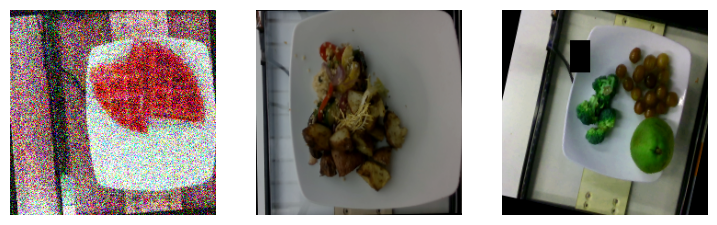

In [60]:
# Берём случайные индексы
indices = random.sample(range(len(dataset)), 3)

fig, axes = plt.subplots(1, 3, figsize=(9,3))
for ax, idx in zip(axes, indices):
    img_pil, label = dataset[idx]
    img_np = np.array(img_pil)
    augmented = transforms(image=img_np)['image']  # numpy HWC
    ax.imshow(augmented)
    ax.axis('off')
plt.show()

На изображениях видно как применяются аугментации: вырезаются случайные участки изображения, добвляется шум и размытие.

## Выводы

Разработаны модули для загрузки и аугментации данных (dataset.py), конфигурационный файл (config.py) и функции обучения/валидации (utils.py) с фиксацией случайности (seed) и расчётом метрик. Реализован воспроизводимый пайплайн, запускаемый одной командой train(cfg, device), с сохранением лучшей модели и логированием результатов.

## Этап 3. Обучение модели

In [ ]:
"""train_full = pd.read_csv('data/imdb_train.csv')
val_full = pd.read_csv('data/imdb_val.csv')

# Создайте маленькие выборки (например, по 100 и 50 строк)
train_debug = train_full.head(50)   # или .sample(100, random_state=42)
val_debug = val_full.head(5)

# Сохраните в отдельные файлы
train_debug.to_csv('data/train_debug.csv', index=False)
val_debug.to_csv('data/val_debug.csv', index=False)"""

In [ ]:
%%time

train(cfg, device)

In [ ]:
# Визуализируем обучение
history_path='training_history.npz'

data = np.load(history_path)
epochs = range(1, len(data['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, data['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, data['val_loss'], label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# График MAE и RMSE
plt.subplot(1, 2, 2)
plt.plot(epochs, data['train_mae'], label='Train MAE', marker='o', linestyle='--')
plt.plot(epochs, data['val_mae'], label='Val MAE', marker='o', linestyle='--')
plt.plot(epochs, data['train_rmse'], label='Train RMSE', marker='s', linestyle='-')
plt.plot(epochs, data['val_rmse'], label='Val RMSE', marker='s', linestyle='-')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('MAE and RMSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Этап 4. Валидация качества

In [12]:
cfg = Config()

In [ ]:
# Токенизатор
tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)

# Трансформации для теста
test_transforms = get_transforms(cfg, ds_type="val")

# Тестовый датасет
test_dataset = MultimodalDataset(cfg, test_transforms, ds_type="test")

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

In [8]:
# Загрузка модели
model = MultimodalModel(cfg)
model.load_state_dict(torch.load(cfg.SAVE_PATH, map_location=device))
model.to(device)
model.eval()

# Инференс
all_preds = []
all_labels = []
all_dish_ids = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device),
            'image': batch['image'].to(device),
            'mass': batch['mass'].to(device),
            'n_ingredients': batch['n_ingredients'].to(device)
        }
        preds = model(**inputs)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(batch['label'].cpu().numpy())
        all_dish_ids.extend(batch['dish_id'])

# Объединение результатов
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Целевая метрика MAE
test_mae = mean_absolute_error(all_labels, all_preds)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 333.8008


In [9]:
# Топ-5 самых неточных предсказаний
errors = np.abs(all_labels - all_preds)
top5_indices = np.argsort(errors)[-5:][::-1]  # 5 наибольших ошибок

print("\nТоп-5 примеров с наибольшей ошибкой:")
for idx in top5_indices:
    print(f"dish_id: {all_dish_ids[idx]}, истина: {all_labels[idx]:.2f}, "
          f"предсказание: {all_preds[idx]:.2f}, ошибка: {errors[idx]:.2f}")


Топ-5 примеров с наибольшей ошибкой:
dish_id: dish_1558637393, истина: 739.97, предсказание: 1.93, ошибка: 738.04
dish_id: dish_1558380557, истина: 699.32, предсказание: 1.93, ошибка: 697.39
dish_id: dish_1563468269, истина: 129.01, предсказание: 1.93, ошибка: 127.08
dish_id: dish_1559700851, истина: 61.09, предсказание: 1.90, ошибка: 59.19
dish_id: dish_1563393217, истина: 49.23, предсказание: 1.93, ошибка: 47.30


In [14]:
# Для более детального анализа загрузим тестовый DataFrame
test_df = pd.read_csv(cfg.TEST_DF_PATH)
top5_df = test_df.iloc[top5_indices]
print("\nДетальная информация по топ-5:")
display(top5_df[['dish_id', 'total_calories', 'total_mass', 'ingredients']])


Детальная информация по топ-5:


,dish_id,total_calories,total_mass,ingredients
0,dish_1561662216,300.794281,193.0,"soy sauce,garlic,white rice,parsley,onions,bro..."
4,dish_1558549773,2.300000,10.0,spinach (raw)
3,dish_1562691032,419.681702,415.0,"berries,olive oil,pineapple,scrambled eggs,roa..."
2,dish_1561739238,274.190002,257.0,"egg whites,hash browns,berries,sweet potato"
1,dish_1562008979,382.936646,290.0,"jalapenos,lemon juice,pork,wheat berry,cabbage..."


## Выводы